In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reemplaza con el nombre exacto de tu archivo si cambia
df = pd.read_csv('/content/Torino_SCA_3months_NOINTERP_2000_2026.csv')

df['period_start'] = pd.to_datetime(df['period_start'])
df['period_end'] = pd.to_datetime(df['period_end'])

print(df.head())
print(df.info())
print(df.describe())

  period_start period_end         sca_ha  valid_images  period_months
0   2000-10-01 2000-12-31  134648.602185            92              3
1   2001-01-01 2001-03-31  171101.300074            90              3
2   2001-04-01 2001-06-30   63526.527313            76              3
3   2001-07-01 2001-09-30    6015.024900            90              3
4   2001-10-01 2001-12-31   82945.190143            92              3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   period_start   102 non-null    datetime64[ns]
 1   period_end     102 non-null    datetime64[ns]
 2   sca_ha         102 non-null    float64       
 3   valid_images   102 non-null    int64         
 4   period_months  102 non-null    int64         
dtypes: datetime64[ns](2), float64(1), int64(2)
memory usage: 4.1 KB
None
              period_start                   

In [4]:
# Ordenar por fecha
df = df.sort_values('period_start').reset_index(drop=True)

# Quitar el último periodo incompleto:
# si tiene menos imágenes que los demás trimestres, lo excluimos
max_valid = df['valid_images'].max()
df_clean = df[df['valid_images'] >= max_valid * 0.95].copy()

print("Filas originales:", len(df))
print("Filas limpias:", len(df_clean))
print(df_clean.tail())

Filas originales: 102
Filas limpias: 96
    period_start period_end         sca_ha  valid_images  period_months
96    2024-10-01 2024-12-31   50362.546701            92              3
97    2025-01-01 2025-03-31  148301.448502            90              3
98    2025-04-01 2025-06-30   54857.164973            91              3
99    2025-07-01 2025-09-30    4184.977761            92              3
100   2025-10-01 2025-12-31   42097.104437            92              3


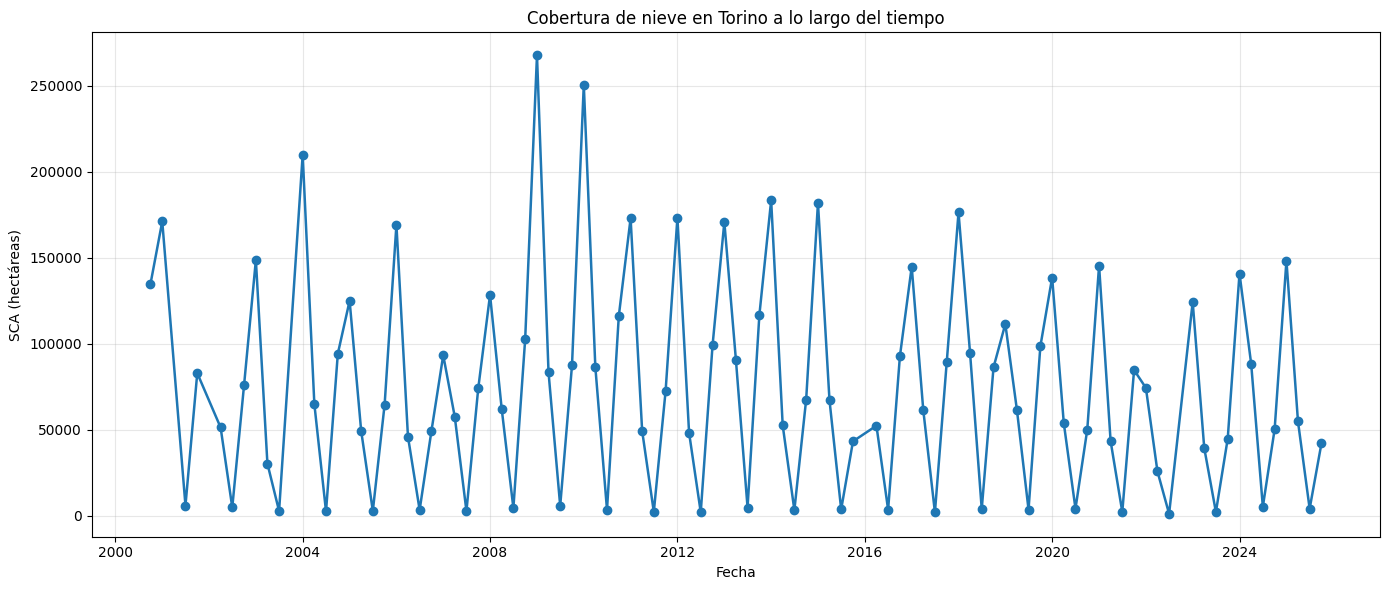

In [5]:
plt.figure(figsize=(14,6))
plt.plot(df_clean['period_start'], df_clean['sca_ha'], marker='o', linewidth=1.8)
plt.title('Cobertura de nieve en Torino a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('SCA (hectáreas)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

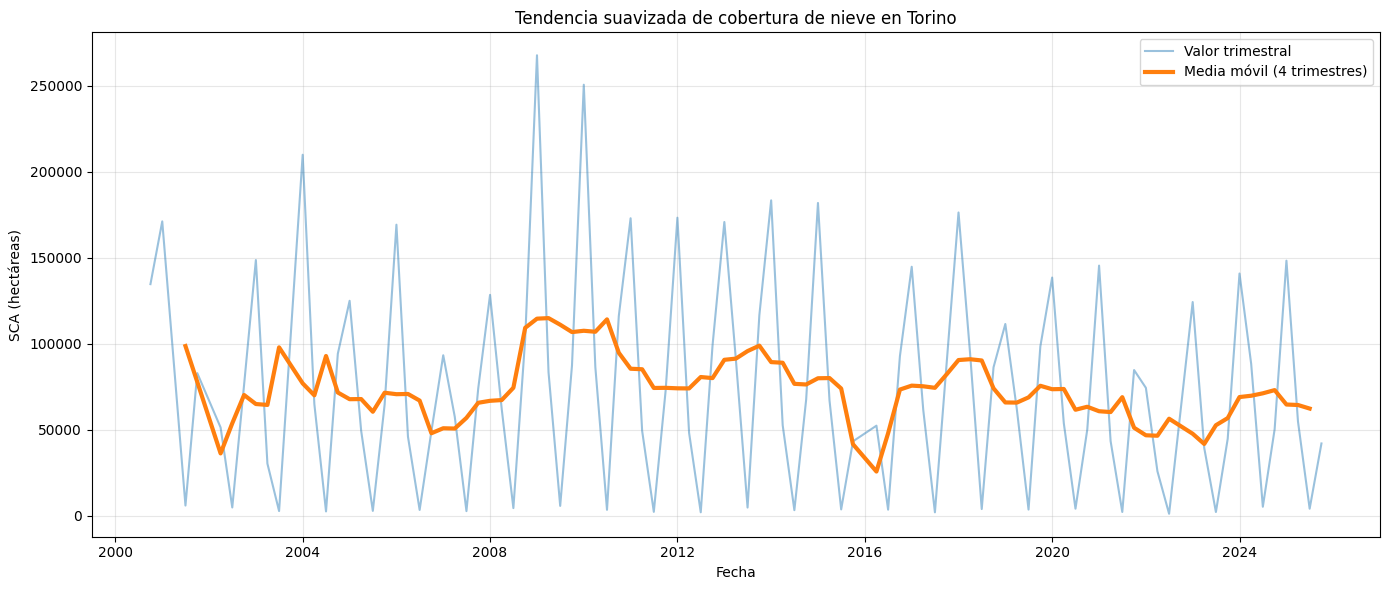

In [6]:
df_clean['sca_rolling'] = df_clean['sca_ha'].rolling(window=4, center=True).mean()

plt.figure(figsize=(14,6))
plt.plot(df_clean['period_start'], df_clean['sca_ha'], alpha=0.45, label='Valor trimestral')
plt.plot(df_clean['period_start'], df_clean['sca_rolling'], linewidth=3, label='Media móvil (4 trimestres)')
plt.title('Tendencia suavizada de cobertura de nieve en Torino')
plt.xlabel('Fecha')
plt.ylabel('SCA (hectáreas)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

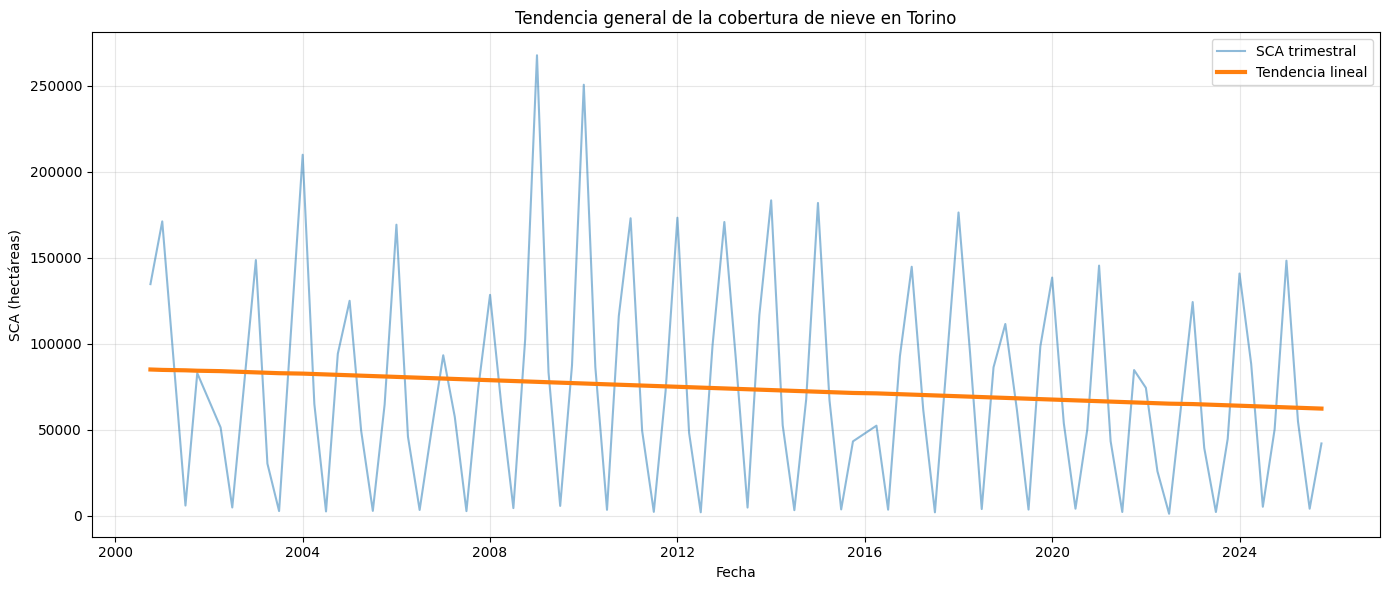

Pendiente por trimestre: -239.14 ha
Pendiente aproximada por año: -956.54 ha/año


In [7]:
x = np.arange(len(df_clean))
y = df_clean['sca_ha'].values

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)(x)

plt.figure(figsize=(14,6))
plt.plot(df_clean['period_start'], y, alpha=0.5, label='SCA trimestral')
plt.plot(df_clean['period_start'], trend, linewidth=3, label='Tendencia lineal')
plt.title('Tendencia general de la cobertura de nieve en Torino')
plt.xlabel('Fecha')
plt.ylabel('SCA (hectáreas)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pendiente por trimestre: {coef[0]:,.2f} ha")
print(f"Pendiente aproximada por año: {coef[0]*4:,.2f} ha/año")

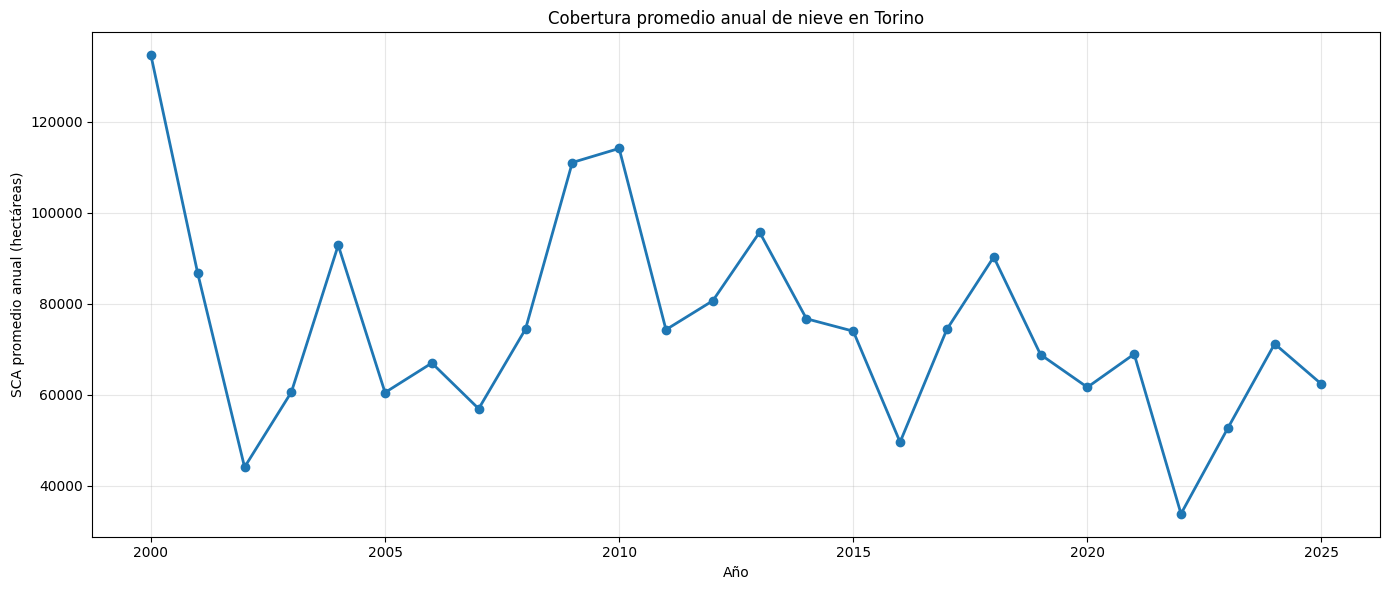

In [8]:
df_clean['year'] = df_clean['period_start'].dt.year

annual = df_clean.groupby('year', as_index=False)['sca_ha'].mean()

plt.figure(figsize=(14,6))
plt.plot(annual['year'], annual['sca_ha'], marker='o', linewidth=2)
plt.title('Cobertura promedio anual de nieve en Torino')
plt.xlabel('Año')
plt.ylabel('SCA promedio anual (hectáreas)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
first_years = annual.head(5)['sca_ha'].mean()
last_years = annual.tail(5)['sca_ha'].mean()

loss_abs = first_years - last_years
loss_pct = (loss_abs / first_years) * 100

print(f"Promedio primeros 5 años: {first_years:,.2f} ha")
print(f"Promedio últimos 5 años: {last_years:,.2f} ha")
print(f"Pérdida estimada: {loss_abs:,.2f} ha")
print(f"Pérdida porcentual estimada: {loss_pct:.2f}%")

Promedio primeros 5 años: 83,792.10 ha
Promedio últimos 5 años: 57,816.56 ha
Pérdida estimada: 25,975.54 ha
Pérdida porcentual estimada: 31.00%


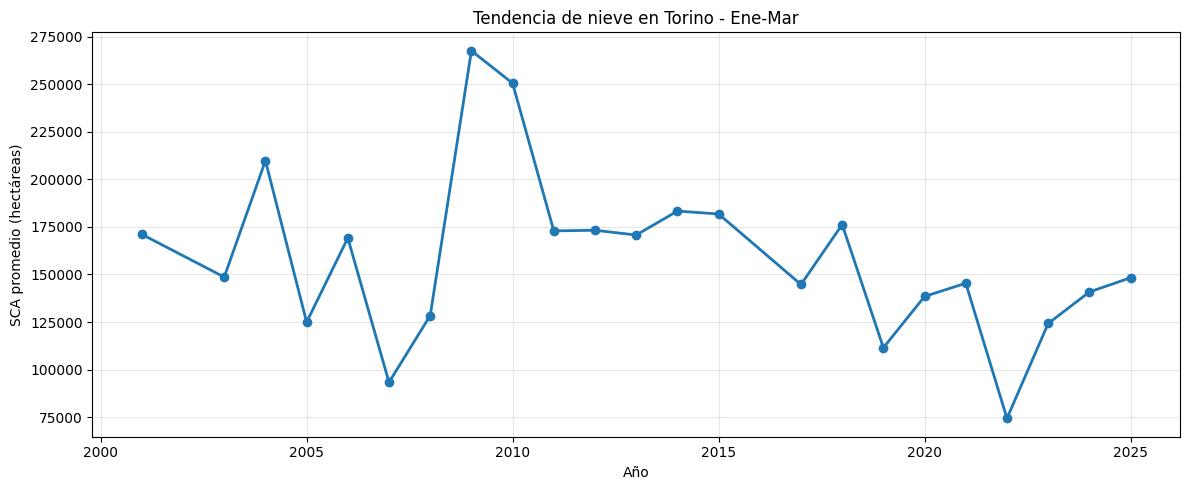

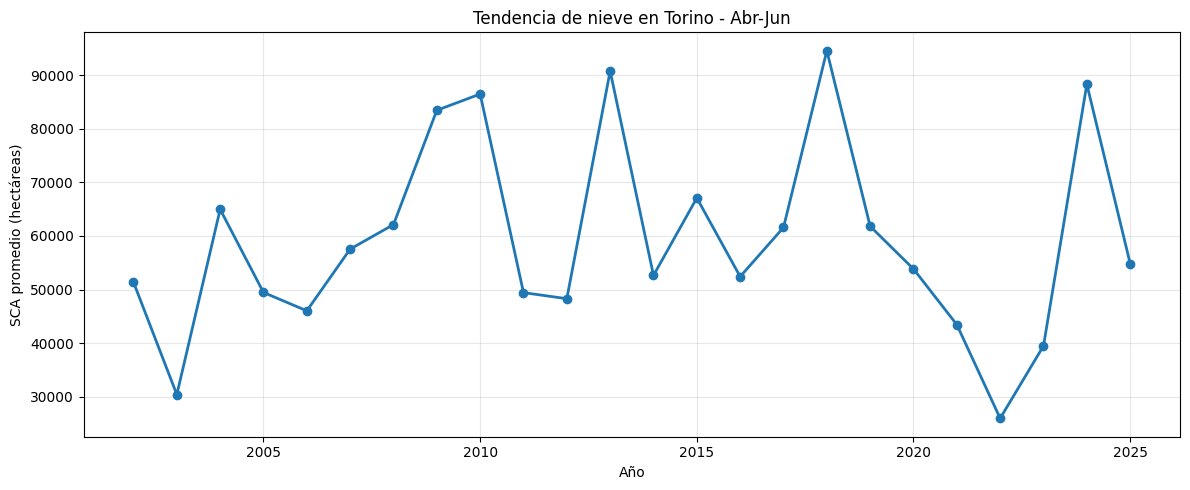

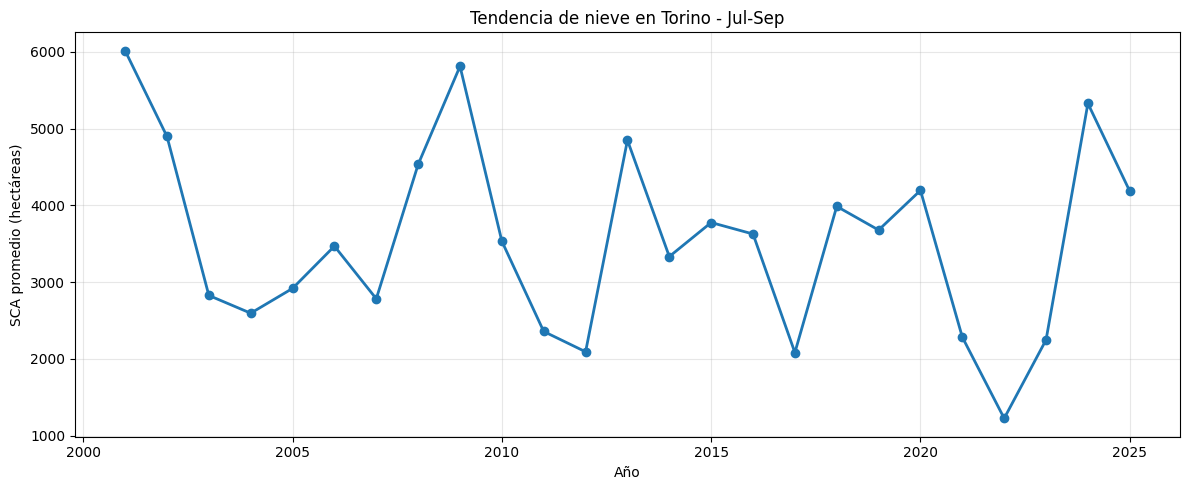

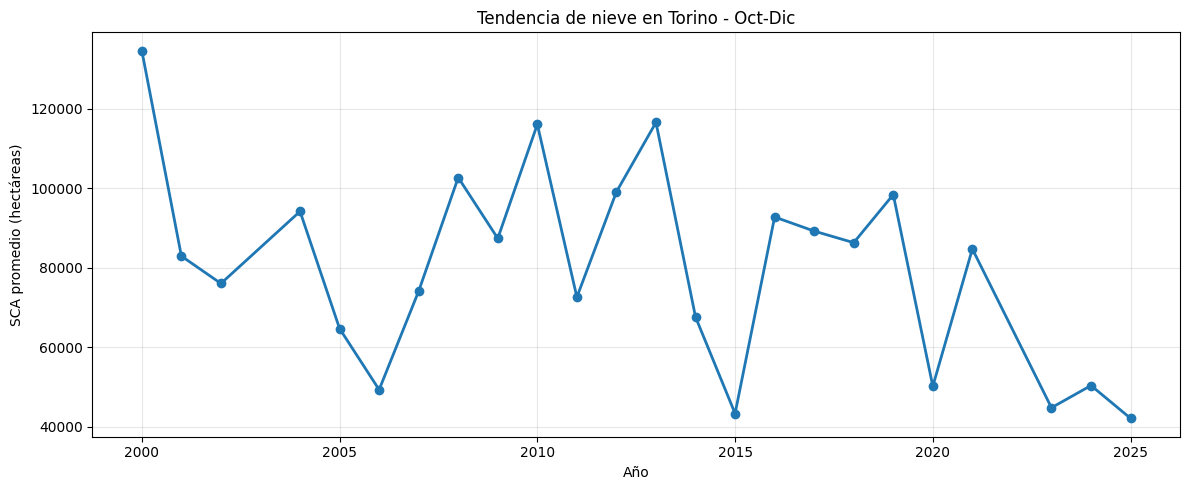

In [10]:
df_clean['quarter'] = df_clean['period_start'].dt.quarter

quarter_labels = {
    1: 'Ene-Mar',
    2: 'Abr-Jun',
    3: 'Jul-Sep',
    4: 'Oct-Dic'
}
df_clean['quarter_name'] = df_clean['quarter'].map(quarter_labels)

seasonal = df_clean.groupby(['year', 'quarter_name'], as_index=False)['sca_ha'].mean()

for q in ['Ene-Mar', 'Abr-Jun', 'Jul-Sep', 'Oct-Dic']:
    temp = seasonal[seasonal['quarter_name'] == q]
    plt.figure(figsize=(12,5))
    plt.plot(temp['year'], temp['sca_ha'], marker='o', linewidth=2)
    plt.title(f'Tendencia de nieve en Torino - {q}')
    plt.xlabel('Año')
    plt.ylabel('SCA promedio (hectáreas)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

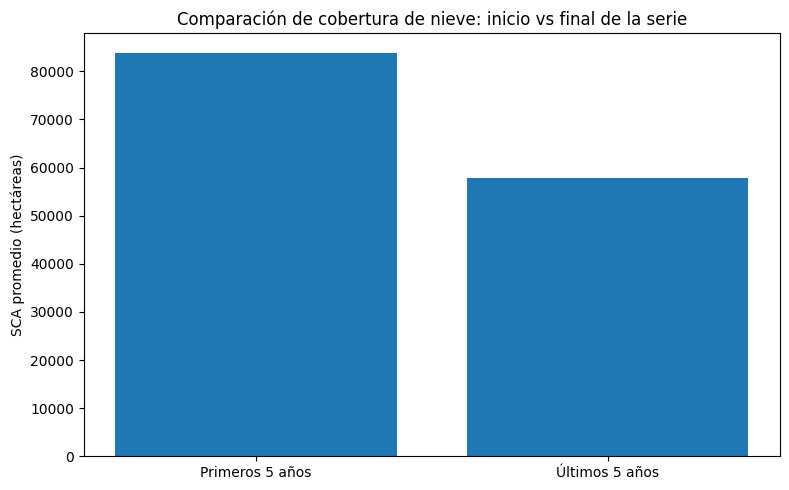

In [11]:
comparison = pd.DataFrame({
    'Periodo': ['Primeros 5 años', 'Últimos 5 años'],
    'SCA_ha': [first_years, last_years]
})

plt.figure(figsize=(8,5))
plt.bar(comparison['Periodo'], comparison['SCA_ha'])
plt.title('Comparación de cobertura de nieve: inicio vs final de la serie')
plt.ylabel('SCA promedio (hectáreas)')
plt.tight_layout()
plt.show()

In [12]:
summary = pd.DataFrame({
    'Métrica': [
        'Promedio primeros 5 años',
        'Promedio últimos 5 años',
        'Pérdida absoluta',
        'Pérdida porcentual'
    ],
    'Valor': [
        round(first_years, 2),
        round(last_years, 2),
        round(loss_abs, 2),
        round(loss_pct, 2)
    ]
})

summary

,Métrica,Valor
0,Promedio primeros 5 años,83792.10
1,Promedio últimos 5 años,57816.56
2,Pérdida absoluta,25975.54
3,Pérdida porcentual,31.00
